In [ ]:
%load_ext autoreload
%autoreload 2

import config
from dindex_store.discovery_index import load_dindex
from aurum_api.algebra import AurumAPI
from qbe_module.query_by_example import ExampleColumn, QueryByExample
from qbe_module.materializer import Materializer
from tqdm import tqdm
import os
import json
from view_distillation import vd
from view_distillation.vd import ViewDistillation
import time
from embedding_module.processor import Processor
from embedding_module.embedding_trainer import EmbeddingTrainer
import networkx as nx



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
cnf = {setting: getattr(config, setting) for setting in dir(config)
       if setting.islower() and len(setting) > 2 and setting[:2] != "__"}

dindex = load_dindex(cnf)
print("Loading DIndex...OK")

api = AurumAPI(dindex)
print("created aurum api")

# QBE interface
qbe = QueryByExample(api)

Initializing profile index: duckdb...
Initializing content similarity index: simpleminhash...
Note that SimpleMHIndex is volatile and so it's not available after loading...
Initializing FTS index: duckdb...
Initializing Graph index: kuzu...
Loading DIndex...OK
created aurum api


In [29]:
"""
Specify an example query
"""
# VER Examples
q1 = ExampleColumn(attr='IATA code airports US states', examples=["Indiana, Georgia, Virginia, Illinois, Connecticut"])
q2 = ExampleColumn(attr='churches US states', examples=["Indiana, Georgia, Virginia, Illinois, Connecticut"])
q3 = ExampleColumn(attr='newspaper company US city', examples=["San Diego", "Boston", "Philadephia"])
q4 = ExampleColumn(attr='population country', examples=["China", "Japan", "United States"])
q5 = ExampleColumn(attr='births per 1000 population country', examples=["China", "Japan", "United States"])

# Date Transform
q6 = ExampleColumn(attr='1 20 2020 date', examples=[])
q7 = ExampleColumn(attr='5 2024 US economy', examples=[])
q8 = ExampleColumn(attr='2000 12 city event', examples=[])
q9 = ExampleColumn(attr='economy US after 2010 10', examples=[])
q10 = ExampleColumn(attr='2015 10 20 political event', examples=[])

# Date Format Transform
q11 = ExampleColumn(attr='01-05-2020 date', examples=[])
q12 = ExampleColumn(attr='01/05/2000 events', examples=[])
q13 = ExampleColumn(attr='country population 22-03-2010', examples=["China", "United States"])
q14 = ExampleColumn(attr='economy US after 01/10/2010', examples=[])
q15 = ExampleColumn(attr='10/20/2015 political event', examples=[])

# Number2Word/Word2Number Transform
q16 = ExampleColumn(attr='US states population over 1000', examples=["Indiana, Georgia, Virginia, Illinois, Connecticut"])
q17 = ExampleColumn(attr='US airports annual flights under 500', examples=[])
q18 = ExampleColumn(attr='US events population under 1000000', examples=[])
q19 = ExampleColumn(attr='newspaper company sell over 1000 monthly', examples=["San Diego", "Boston", "Philadephia"])
q20 = ExampleColumn(attr='births per 1000 population country', examples=["China", "Japan", "United States"])

# Stemming Transform
q21 = ExampleColumn(attr='IATA code airports US states', examples=["Indianapolis, Atlanta, Richmond, Chicago, Hartford"])
q22 = ExampleColumn(attr='churches US states', examples=["Indiana, Georgia, Virginia, Illinois, Connecticut"])
q23 = ExampleColumn(attr='newspaper companies US city', examples=["San Diego", "Boston", "Philadephia"])
q24 = ExampleColumn(attr='population countries', examples=["China", "Japan", "United States"])
q25 = ExampleColumn(attr='births per 1000 population country', examples=["China", "Japan", "United States"])

# QueryFilter Tests
q26 = ExampleColumn(attr='05/01/2000', examples=[])
q27 = ExampleColumn(attr='01-05-2000', examples=[])
q28 = ExampleColumn(attr='01-05-2020', examples=[])
q29 = ExampleColumn(attr='05/01/2020', examples=[])
filterQueries = [q26, q27, q28, q29]


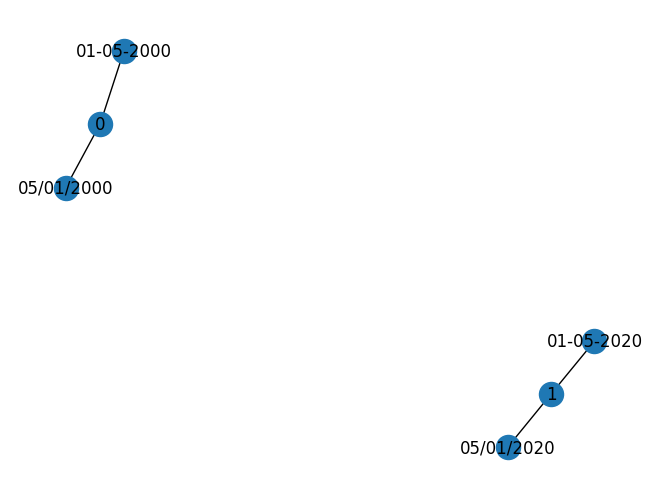

In [37]:
from transform_module import query_filter, transform
qf = query_filter.QueryFilter(transform.DateFormatTransform(), filterQueries)
fq = qf.filter_queries()
graph = qf.generate_graph()

nx.draw(graph, with_labels=True)

In [4]:
eq1 = qbe.find_similar_columns(q1, top_k=5)
eq2 = qbe.find_similar_columns(q2, top_k=5)
eq3 = qbe.find_similar_columns(q3, top_k=5)
eq4 = qbe.find_similar_columns(q4, top_k=5)
eq5 = qbe.find_similar_columns(q5, top_k=5)


In [ ]:
eq6 = transform.DateTransform().apply_transform([q6])
eq7 = transform.DateTransform().apply_transform([q7])
eq8 = transform.DateTransform().apply_transform([q8])
eq9 = transform.DateTransform().apply_transform([q9])
eq10 = transform.DateTransform().apply_transform([q10])

eq11 = transform.DateFormatTransform().apply_transform([q11])
eq12 = transform.DateFormatTransform().apply_transform([q12])
eq13 = transform.DateFormatTransform().apply_transform([q13])
eq14 = transform.DateFormatTransform().apply_transform([q14])
eq15 = transform.DateFormatTransform().apply_transform([q15])

eq16 = transform.NumberToWordTransform().apply_transform([q16])
eq17 = transform.NumberToWordTransform().apply_transform([q17])
eq18 = transform.NumberToWordTransform().apply_transform([q18])
eq19 = transform.NumberToWordTransform().apply_transform([q19])
eq20 = transform.NumberToWordTransform().apply_transform([q20])

eq21 = transform.StemmingTransform().apply_transform([q21])
eq22 = transform.StemmingTransform().apply_transform([q22])
eq23 = transform.StemmingTransform().apply_transform([q23])
eq24 = transform.StemmingTransform().apply_transform([q24])
eq25 = transform.StemmingTransform().apply_transform([q25])


In [6]:
for q in eq25:
    print(q.attr, q.examples)

births per 1000 population country ['China', 'Japan', 'United States']
birth ['China', 'Japan', 'United States']
per ['China', 'Japan', 'United States']
1000 ['China', 'Japan', 'United States']
popul ['China', 'Japan', 'United States']
countri ['China', 'Japan', 'United States']


In [82]:
with open("queries.json", "r") as f:
    queries = json.load(f)

all_queries = []
for q in queries["queries"]:
    all_queries.append(ExampleColumn(attr=q["query"], examples=[]))

print(len(all_queries))


1947


In [85]:
"""
Find candidate columns
"""
start = time.time()
candidate_list = qbe.find_candidate_columns([all_queries[0]], cluster_prune=False)
uniq_candidate_list = set()

# take out all empty lists
# candidate_list = [col for col in candidate_list if len(col) > 0]

# so basically finds all different columns that have value same as attr or similar

print("Time taken to find candidate columns: ", time.time() - start)

"""
Display candidate columns (for debugging purpose)
"""
total = 0
for i, candidate in enumerate(candidate_list):
    # print('column {}: found {} candidate columns'.format(format(i), len(candidate)))
    uniq_candidate_list.update(candidate)
    total += len(candidate)

    # for debugging purpose, print the candidate columns
    # for col in candidate:
    #     print(col.to_str(), col.examples_set)
print("Total number of candidate columns: ", total)
print("Total number of unique candidate columns: ", len(uniq_candidate_list))

Time taken to find candidate columns:  0.05785322189331055
Total number of candidate columns:  50
Total number of unique candidate columns:  50


In [77]:
# CANDIDATE GROUPS
candidate_tbls = [set() for _ in candidate_list] 
cand_groups, tbl_cols = qbe.find_candidate_groups(candidate_list)
# takes in List[List[Column]]

print("number of candidate groups: ", len(cand_groups))

# """
# Find join graphs
# """
number_of_cand_groups_to_search = 200
join_graphs = qbe.find_join_graphs_for_cand_groups(cand_groups[0:number_of_cand_groups_to_search])
print(f"number of join graphs: {len(join_graphs)}")

number of candidate groups:  1


100%|██████████| 1/1 [00:00<00:00, 13315.25it/s]

number of join graphs: 1


In [78]:
data_path = './WDC_data/'  # path where the raw data is stored
output_path = './output/'  # path to store the output views
max_num_views = 1000  # how many views you want to materialize
sep = ','  # csv separator

if not os.path.exists(output_path):
    os.makedirs(output_path)
materializer = Materializer(data_path, tbl_cols, 200, sep)

result_dfs = []

j = 0
for join_graph in tqdm(join_graphs):
    """
    a join graph can produce multiple views because different columns are projected
    """
    df_list = materializer.materialize_join_graph(join_graph)
    for df in df_list:
        if len(df) != 0:
            metadata = {}
            metadata["join_graph"] = join_graph.to_str()
            metadata["columns_proj"] = list(df.columns)
            with open(f"./{output_path}/view{j}.json", "w") as outfile:
                json.dump(metadata, outfile)
            j += 1
            print("non empty view", j)
            new_cols = []
            k = 1
            for col in df.columns:
                new_col = col.split(".")[-1]
                if new_col in new_cols:
                    new_col += str(k)
                    k += 1
                new_cols.append(new_col)
            df.columns = new_cols
            df.to_csv(f"./{output_path}/view{j}.csv", index=False)

            result_dfs.append(df)

    if j >= max_num_views:
        break

print("valid views", j)


100%|██████████| 1/1 [00:00<00:00, 32.44it/s]

non empty view 1
valid views 1


In [ ]:
vd = ViewDistillation(dfs=result_dfs)

# Generates a networkx graph representing 4C relationships among views (nodes)
vd.generate_graph()

# Prune the graph with the given pruning strategies, returning the updated graph
graph = vd.prune_graph(remove_identical_views=True,
                       remove_contained_views=True,
                       union_complementary_views=True)



original num views: 1
num views after pruning compatible: 1
num views after pruning contained: 1
num views after union complementary: 1
num of contradictory view pairs: 0
